In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense

In [74]:
data = load_iris()

df = pd.DataFrame(
  columns=[*data.feature_names, 'label'],
  data=np.hstack(
    (data.data, data.target.reshape((150, 1)).astype(int))
  )
)

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [112]:
from keras.layers import Input
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from keras.metrics import Precision, Recall
from keras.regularizers import l2

model = Sequential([
  Input(shape=(data.data.shape[1],)),
  Dense(3, activation='softmax', kernel_regularizer=l2())
])

model.compile(
  loss='categorical_crossentropy', 
  optimizer='adam',
  metrics=[
    'accuracy',
    Precision(name='precision'),
    Recall(name='recall'),
  ]
)

In [113]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, stratify=y, random_state=42
)

ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

y_train_encoded = to_categorical(y_train, num_classes=3)
y_test_encoded = to_categorical(y_test, num_classes=3)

In [114]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
  X_train_scaled, y_train_encoded,
  validation_data=(X_test_scaled, y_test_encoded),
  batch_size=16, epochs=100,
  callbacks=[early_stop]
)

print(f"Training stopped at epoch {len(history.history['loss'])}")
print(f"Final train accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final train precision: {history.history['precision'][-1]:.4f}")
print(f"Final train recall: {history.history['recall'][-1]:.4f}")
print(f"Final val accuracy: {history.history['val_accuracy'][-1]:.4f}")

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.2000 - loss: 1.6884 - precision: 0.0638 - recall: 0.0250 - val_accuracy: 0.2000 - val_loss: 1.6180 - val_precision: 0.0833 - val_recall: 0.0333
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2333 - loss: 1.6591 - precision: 0.1042 - recall: 0.0417 - val_accuracy: 0.3000 - val_loss: 1.5886 - val_precision: 0.1538 - val_recall: 0.0667
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2500 - loss: 1.6280 - precision: 0.1429 - recall: 0.0583 - val_accuracy: 0.3333 - val_loss: 1.5611 - val_precision: 0.1538 - val_recall: 0.0667
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2500 - loss: 1.6000 - precision: 0.2075 - recall: 0.0917 - val_accuracy: 0.3667 - val_loss: 1.5330 - val_precision: 0.1429 - val_recall: 0.0667
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2667 - loss: 1.5712 - precision: 0.2037 - recall: 0.0917 - val_accuracy: 0.3667 - val_loss: 1.5056 - va

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.2000 - loss: 1.6884 - precision: 0.0638 - recall: 0.0250 - val_accuracy: 0.2000 - val_loss: 1.6180 - val_precision: 0.0833 - val_recall: 0.0333
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2333 - loss: 1.6591 - precision: 0.1042 - recall: 0.0417 - val_accuracy: 0.3000 - val_loss: 1.5886 - val_precision: 0.1538 - val_recall: 0.0667
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2500 - loss: 1.6280 - precision: 0.1429 - recall: 0.0583 - val_accuracy: 0.3333 - val_loss: 1.5611 - val_precision: 0.1538 - val_recall: 0.0667
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2500 - loss: 1.6000 - precision: 0.2075 - recall: 0.0917 - val_accuracy: 0.3667 - val_loss: 1.5330 - val_precision: 0.1429 - val_recall: 0.0667
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2667 - loss: 1.5712 - precision: 0.2037 - recall: 0.0917 - val_accuracy: 0.3667 - val_loss: 1.5056 - va

KeyError: 'f1-score'

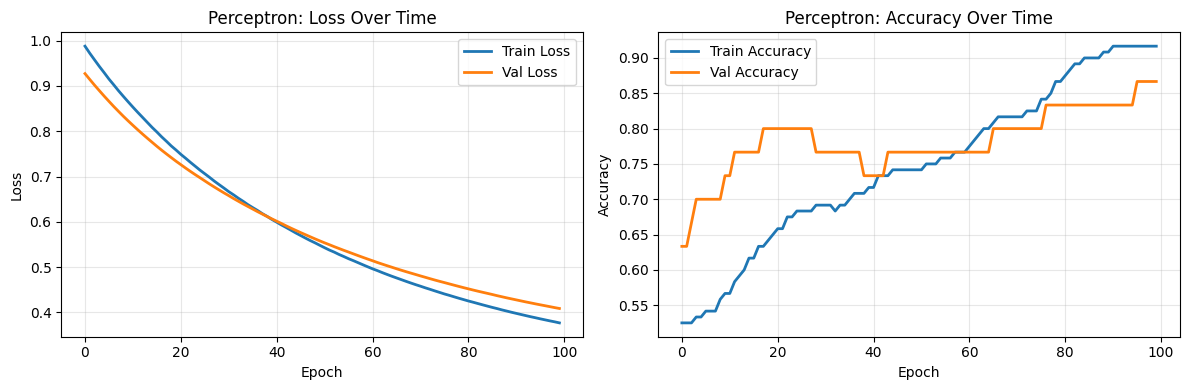

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Perceptron: Loss Over Time')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Perceptron: Accuracy Over Time')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.60      0.75        10
   virginica       0.71      1.00      0.83        10

    accuracy                           0.87        30
   macro avg       0.90      0.87      0.86        30
weighted avg       0.90      0.87      0.86        30


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.60      0.75        10
   virginica       0.71      1.00      0.83        10

    accuracy                           0.87        30
   macro avg       0.90      0.87      0.86        30
weighted avg       0.90      0.87      0.86        30



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.60      0.75        10
   virginica       0.71      1.00      0.83        10

    accuracy                           0.87        30
   macro avg       0.90      0.87      0.86        30
weighted avg       0.90      0.87      0.86        30


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.60      0.75        10
   virginica       0.71      1.00      0.83        10

    accuracy                           0.87        30
   macro avg       0.90      0.87      0.86        30
weighted avg       0.90      0.87      0.86        30



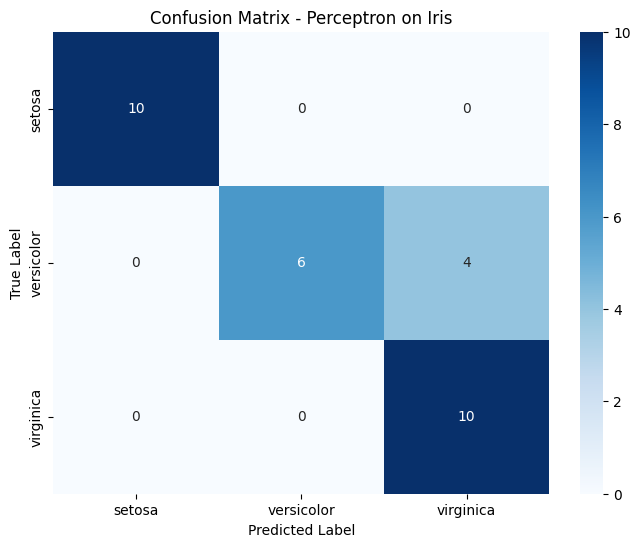

In [87]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.values

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=data.target_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title('Confusion Matrix - Perceptron on Iris')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()